In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
rng = np.random.default_rng(42)
import ipywidgets as widgets
from ipywidgets import interact, interactive_output
from IPython.display import display, Markdown

---
## 1. Cargar y conocer la población

In [4]:
df = pd.read_parquet("../data/ClimaLab_2023-05-31_2025-06-20.parquet")

# Teorema de limite central

Objetivos:

1. Tomar tdb del conjunto de datos y definir K subconjuntos de tamaño n, definidos en el inicio de la celda y calcular la media. Si K > 1, graficar juntos el promedio con un bin también definido por el usuario, para poder ver como se va cumpliendo el teorema de limite central.
2. Una vez definido un tamaño de muestra, y considerando que se conoce el promedio de tdb, calcular la desviación estándard y promedio del subconjunto y compararlo con sigma  = sigma_hat * sqr( (1- 1/N)/(1-(1/n))), donde N es el tamaño del conjunto tdb

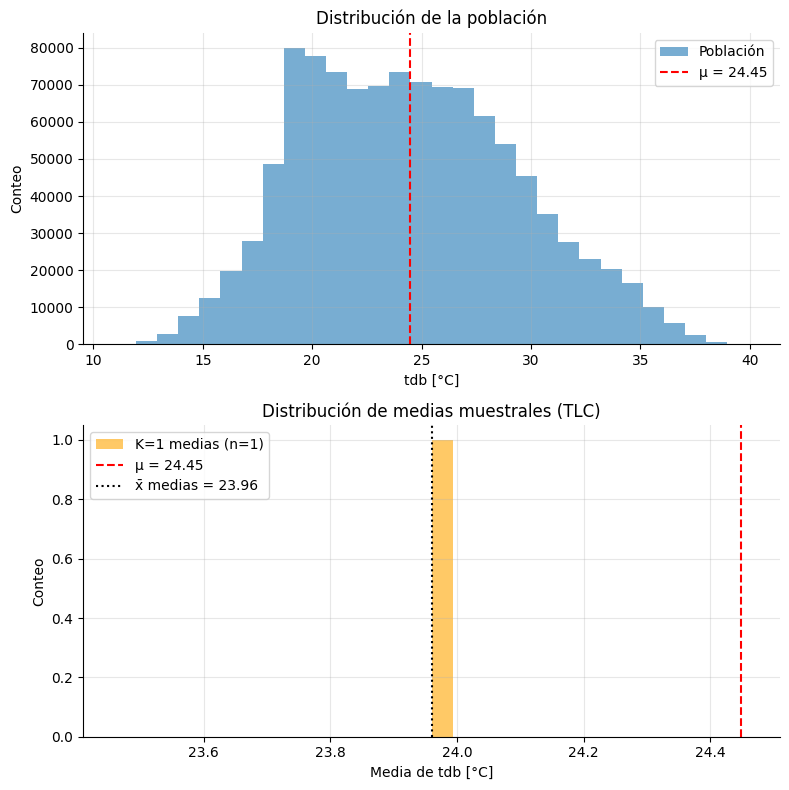

Población:  μ = 24.4479,  σ = 4.9352,  N = 1076768
Medias:     x̄ = 23.9600,  s = 0.0000,  K = 1


In [72]:
# --- Objetivo 1: Teorema de Límite Central ---
tdb = df["tdb"].dropna().values
N = len(tdb)

n = 1       # tamaño de cada subconjunto
K = 1        # número de repeticiones
bins = 30     # bins del histograma

medias = np.array([rng.choice(tdb, size=n, replace=False).mean() for _ in range(K)])

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].hist(tdb, bins=bins, density=False, alpha=0.6, label="Población")
axes[0].axvline(tdb.mean(), color="red", ls="--", label=f"μ = {tdb.mean():.2f}")
axes[0].set(xlabel="tdb [°C]", ylabel="Conteo", title="Distribución de la población")
axes[0].legend()

axes[1].hist(medias, bins=bins, density=False, alpha=0.6, color="orange", label=f"K={K} medias (n={n})")
axes[1].axvline(tdb.mean(), color="red", ls="--", label=f"μ = {tdb.mean():.2f}")
axes[1].axvline(medias.mean(), color="black", ls=":", label=f"x̄ medias = {medias.mean():.2f}")
axes[1].set(xlabel="Media de tdb [°C]", ylabel="Conteo", title="Distribución de medias muestrales (TLC)")
axes[1].legend()
# axes[1].set_xlim(min(tdb),max(tdb))

plt.tight_layout()
plt.show()

print(f"Población:  μ = {tdb.mean():.4f},  σ = {tdb.std():.4f},  N = {N}")
print(f"Medias:     x̄ = {medias.mean():.4f},  s = {medias.std():.4f},  K = {K}")

In [56]:

n = 1000       # tamaño de cada subconjunto



# --- Objetivo 2: Comparación σ teórica vs σ observada ---
muestra = rng.choice(tdb, size=n, replace=False)

media_muestra = muestra.mean()
sigma_muestra = muestra.std()

# sigma corregida por población finita
sigma_teorica = sigma_muestra * np.sqrt((1 - 1/N) / (1 - 1/n))

print(f"Tamaño de muestra:    n = {n}")
print(f"Tamaño de población:  N = {N}")
print()
print(f"Media población (μ):          {tdb.mean():.4f} °C")
print(f"Media muestra (x̄):            {media_muestra:.4f} °C")
# print(f"Diferencia |μ - x̄|:           {abs(tdb.mean() - media_muestra):.4f} °C")
print()
print(f"σ̂ muestra ():                 {sigma_muestra:.4f} °C")
print(f"σ población real:             {tdb.std():.4f} °C")
print(f"σ corregida (teórica):        {sigma_teorica:.4f} °C")
print(f"Diferencia |σ_real - σ_teór|: {abs(tdb.std() - sigma_teorica):.4f} °C")

Tamaño de muestra:    n = 1000
Tamaño de población:  N = 1076768

Media población (μ):          24.4479 °C
Media muestra (x̄):            24.3031 °C

σ̂ muestra ():                 4.9748 °C
σ población real:             4.9352 °C
σ corregida (teórica):        4.9773 °C
Diferencia |σ_real - σ_teór|: 0.0422 °C


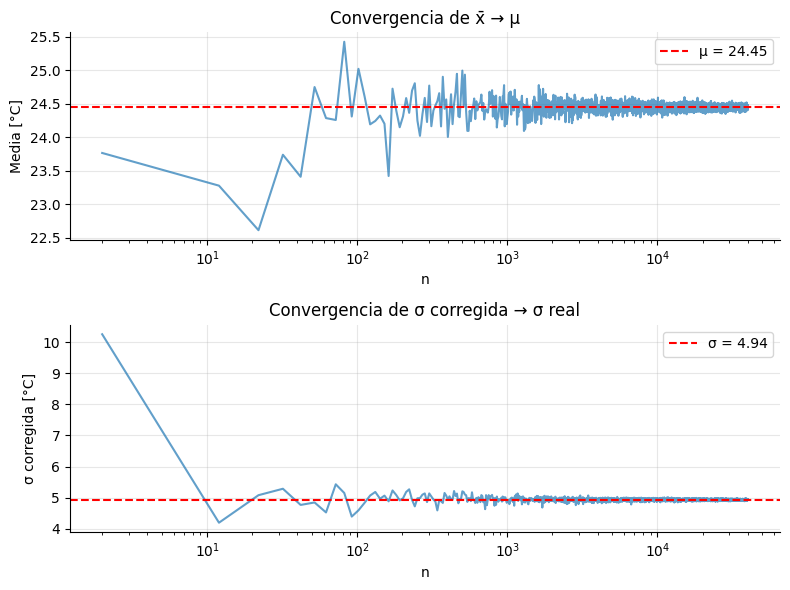

In [69]:
valores_n = np.arange(2, 40000, 10)
medias_n = np.zeros(len(valores_n))
sigmas_corregidas = np.zeros(len(valores_n))

for i, n in enumerate(valores_n):
  muestra = rng.choice(tdb, size=n, replace=False)
  medias_n[i] = muestra.mean()
  sigma_hat = muestra.std(ddof=1)
  sigmas_corregidas[i] = sigma_hat * np.sqrt((1 - 1/N) / (1 - 1/n))

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(valores_n, medias_n, alpha=0.7)
axes[0].axhline(tdb.mean(), color="red", ls="--", label=f"μ = {tdb.mean():.2f}")
axes[0].set(xlabel="n", ylabel="Media [°C]", title="Convergencia de x̄ → μ")
axes[0].set_xscale("log")
axes[0].legend()

axes[1].plot(valores_n, sigmas_corregidas, alpha=0.7)
axes[1].axhline(tdb.std(), color="red", ls="--", label=f"σ = {tdb.std():.2f}")
axes[1].set(xlabel="n", ylabel="σ corregida [°C]", title="Convergencia de σ corregida → σ real")
axes[1].set_xscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

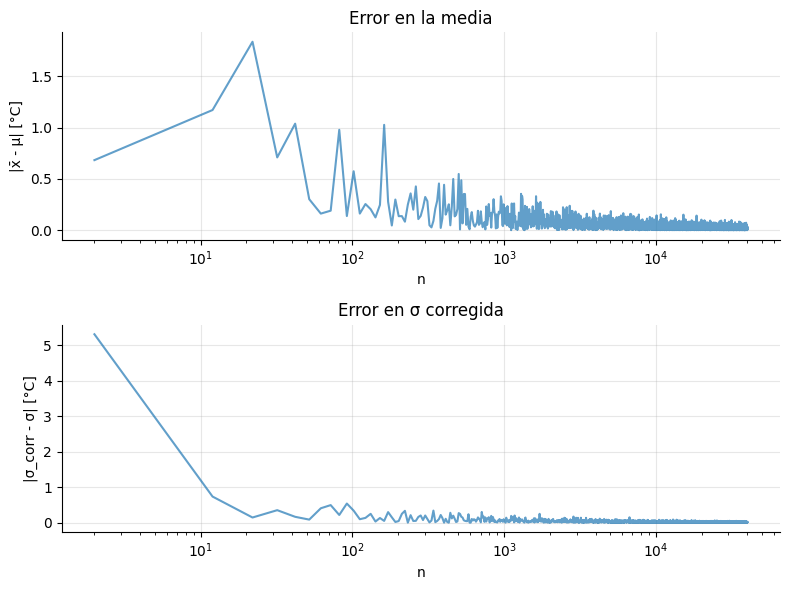

In [71]:

error_media = np.abs(medias_n - tdb.mean())
error_sigma = np.abs(sigmas_corregidas - tdb.std())

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(valores_n, error_media, alpha=0.7)
axes[0].set(xlabel="n", ylabel="|x̄ - μ| [°C]", title="Error en la media")
axes[0].set_xscale("log")

axes[1].plot(valores_n, error_sigma, alpha=0.7)
axes[1].set(xlabel="n", ylabel="|σ_corr - σ| [°C]", title="Error en σ corregida")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()